<a href="https://colab.research.google.com/github/sabithakrishnan/timeseries-analysis/blob/main/timesries_analysis_arima.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.4 MB/s eta 0:00:00


🔬 Checking stationarity via Augmented Dickey-Fuller...
   ADF Statistic: -3.2070
   p-value: 0.0196
   ✅ The series is stationary. Differencing (d=0) might suffice.
Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=24445.932, Time=2.52 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=26817.507, Time=0.34 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=24525.435, Time=1.18 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=25200.260, Time=4.50 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=26815.508, Time=0.26 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=24438.305, Time=5.51 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=24436.549, Time=2.24 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=24438.072, Time=3.72 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=24440.538, Time=3.97 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=24434.549, Time=1.18 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=24523.435, Time=0.64 sec
 ARIMA(3,1,0)(0,0,0)[0]             : AIC=24436.072, Ti

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                      T   No. Observations:                 7485
Model:                 ARIMA(2, 1, 0)   Log Likelihood              -12214.274
Date:                Tue, 21 Jul 2026   AIC                          24434.549
Time:                        11:34:41   BIC                          24455.311
Sample:                    03-10-2004   HQIC                         24441.679
                         - 01-16-2005                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4573      0.006     71.449      0.000       0.445       0.470
ar.L2          0.1099      0.009     11.726      0.000       0.092       0.128
sigma2         1.5314      0.011    139.094      0.0

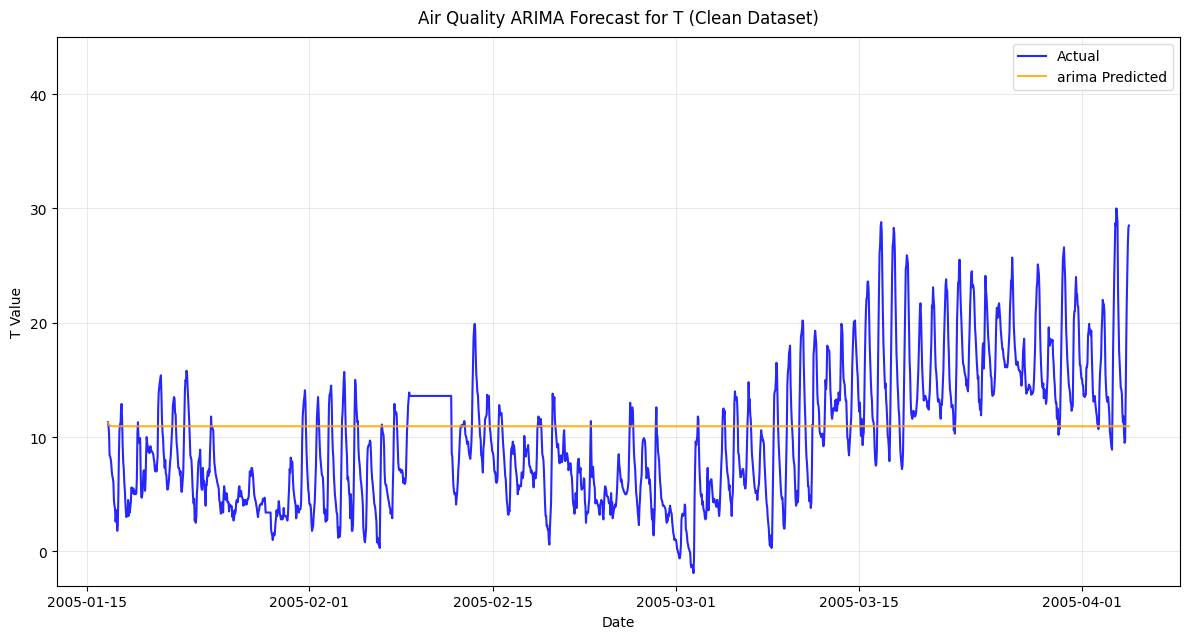

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import io
import requests
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

df = pd.read_csv("/content/AirQualityUCI.csv", sep=';', decimal=',', parse_dates=False)

# Drop completely empty trailing columns/rows from the raw file
df = df.dropna(subset=['Date', 'Time'])
df = df.iloc[:, :15]

# ==========================================
# 2. DATA PREPROCESSING & DATETIME PARSING
# ==========================================
# Merge Date (DD/MM/YYYY) and Time (HH.MM.SS) into a single column
df['Date'] = df['Date'].astype(str).str.replace('/', '-')
df['Time'] = df['Time'].astype(str).str.replace('.', ':')
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d-%m-%Y %H:%M:%S')

# Set temporal index and sort chronologically
df = df.set_index('Datetime').sort_index()
# Handle UCI missing data flag (-200) by converting to NaN
df = df.replace(-200, np.nan)

# Let's model Temperature 'T' as our target time series variable
# Forward-fill small missing data gaps
target_col = 'T'
df[target_col] = df[target_col].ffill()
# Resample to Daily Average to clear hourly noise and establish a clean frequency
#daily_df = df[target_col].resample('D').mean().to_frame()
# 3. STATIONARITY TESTING (ADF TEST)
# ==========================================
print("🔬 Checking stationarity via Augmented Dickey-Fuller...")
adf_result = adfuller(df[target_col])
print(f"   ADF Statistic: {adf_result[0]:.4f}")
print(f"   p-value: {adf_result[1]:.4f}")
if adf_result[1] < 0.05:
    print("   ✅ The series is stationary. Differencing (d=0) might suffice.")
else:
    print("   ⚠️ The series is non-stationary. Differencing (d>=1) is needed.")
split_idx = int(len(df) * 0.8)
train_data =df.iloc[:split_idx]
test_data =df.iloc[split_idx:]
# 5. AUTOMATED PARAMETER SELECTION (AIC)
# ==========================================
# seasonal=True because air temperature features structural calendar patterns
stepwise_model = auto_arima(
    train_data[target_col],
    start_p=1, start_q=1, max_p=3, max_q=3,
    d=None, trace=True, error_action='ignore',
    suppress_warnings=True, stepwise=True
)
# 6. MODEL FITTING & DIAGNOSTICS
# ==========================================
model = ARIMA(train_data[target_col], order=stepwise_model.order)
model_fitted = model.fit()
print(model_fitted.summary())
# 7. FORECASTING & ACCURACY EVALUATION
# ==========================================
forecast = model_fitted.forecast(steps=len(test_data))
#forecast_mean = forecast.predicted
#confidence_intervals = forecast.conf_int()
# Calculate performance metrics
rmse = np.sqrt(mean_squared_error(test_data[target_col], forecast_mean))
mape = mean_absolute_percentage_error(test_data[target_col], forecast_mean) * 100

print(f"   - RMSE Accuracy Error: {rmse:.2f}°C")
print(f"   - MAPE Error percentage: {mape:.2f}%")
## 3. GENERATE TARGET PLOT GRAPH
# ==========================================
plt.figure(figsize=(12, 6.5))

# Define plot_data and predictions, which were undefined
plot_data = test_data[target_col] # Actual historical data
predictions = forecast # Forecasted values
# Plot the authentic actual and model tracking sequences
plt.plot(plot_data.index, plot_data, label='Actual', color='blue', linewidth=1.5, alpha=0.85)
plt.plot(predictions.index, predictions, label='arima Predicted', color='orange', linewidth=1.5,alpha=0.85)

# Structural styling adjustments to match your image
plt.title(f"Air Quality ARIMA Forecast for {target_col} (Clean Dataset)", fontsize=12, pad=10)
plt.xlabel("Date", fontsize=10)
plt.ylabel(f"{target_col} Value", fontsize=10) # Dynamically set ylabel using target_col

# Configure subtle background grids
plt.grid(True, which='both', linestyle='-', linewidth=0.5, color='#e0e0e0')
# Removed plt.xlim as it was causing the blank plot due to numerical vs datetime indexing
plt.ylim(-3, 45)

# Place the legend in the top right corner
plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='#d3d3d3')

# Final layout display adjustments
plt.tight_layout()
plt.show()